In [10]:
!pip install lifelines

In [11]:
# Libraries
import pandas as pd

In [16]:
# Import the dataset
dataset = pd.read_csv("data/lung.csv")
dataset = dataset.dropna()
dataset.head()

,inst,time,status,age,sex,ph.ecog,ph.karno,pat.karno,meal.cal,wt.loss
1,3.0,455,2,68,1,0.0,90.0,90.0,1225.0,15.0
3,5.0,210,2,57,1,1.0,90.0,60.0,1150.0,11.0
5,12.0,1022,1,74,1,1.0,50.0,80.0,513.0,0.0
6,7.0,310,2,68,2,2.0,70.0,60.0,384.0,10.0
7,11.0,361,2,71,2,2.0,60.0,80.0,538.0,1.0


In [17]:
# Data organization
dataset.loc[dataset.status == 1, "status"] = 0
dataset.loc[dataset.status == 2, "status"] = 1

In [18]:
# Get only variables needed
dataset = dataset.drop(columns = ["inst"])
dataset

,time,status,age,sex,ph.ecog,ph.karno,pat.karno,meal.cal,wt.loss
1,455,1,68,1,0.0,90.0,90.0,1225.0,15.0
3,210,1,57,1,1.0,90.0,60.0,1150.0,11.0
5,1022,0,74,1,1.0,50.0,80.0,513.0,0.0
6,310,1,68,2,2.0,70.0,60.0,384.0,10.0
7,361,1,71,2,2.0,60.0,80.0,538.0,1.0
...,...,...,...,...,...,...,...,...,...
221,203,0,71,2,1.0,80.0,90.0,1025.0,0.0
224,191,0,39,1,0.0,90.0,90.0,2350.0,-5.0
225,105,0,75,2,2.0,60.0,70.0,1025.0,5.0
226,174,0,66,1,1.0,90.0,100.0,1075.0,1.0


In [19]:
# Cox Proportional hazard
from lifelines import CoxPHFitter
model = CoxPHFitter()
model.fit(dataset, "time", event_col = "status")
model.print_summary()

<lifelines.CoxPHFitter: fitted with 167 total observations, 47 right-censored observations>
             duration col = 'time'
                event col = 'status'
      baseline estimation = breslow
   number of observations = 167
number of events observed = 120
   partial log-likelihood = -494.03
         time fit was run = 2026-03-09 20:43:16 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
age        0.01      1.01      0.01           -0.01            0.03                0.99                1.03
sex       -0.55      0.57      0.20           -0.95           -0.16                0.39                0.85
ph.ecog    0.74      2.09      0.22            0.30            1.18                1.35                3.26
ph.karno   0.02      1.02      0.01            0.00            0.04                1.00                1.05
pat.karno -0.01      0.99      0.01           -0.03            0.00                0.97                1.00
meal.cal   0.00      1.00      0.00           -0.00            0.00                1.00                1.00
wt.loss   -0.01      0.99      0.01           -0.03            0.00                0.97                1.00

           cmp to     z      p  -log2(p)
covariate                               
age          0.00  0.93   0.35      1.51
sex          0.00 -2.75   0.01      7.37
ph.ecog      0.00  3.29 <0.005      9.95
ph.karno     0.00  2.00   0.05      4.45
pat.karno    0.00 -1.49   0.14      2.87
meal.cal     0.00  0.11   0.91      0.13
wt.loss      0.00 -1.83   0.07      3.89
---
Concordance = 0.65
Partial AIC = 1002.07
log-likelihood ratio test = 28.16 on 7 df
-log2(p) of ll-ratio test = 12.25

<Axes: xlabel='log(HR) (95% CI)'>

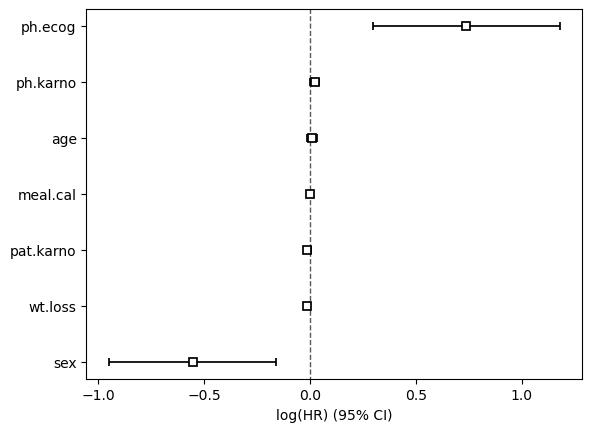

In [20]:
# Plotting
model.plot()

In [21]:
# Import the dataset
import pandas as pd
dataset = pd.read_csv("data/veteran.csv")
dataset = dataset.dropna()
dataset.head()

,trt,celltype,time,status,karno,diagtime,age,prior
0,1,squamous,72,1,60,7,69,0
1,1,squamous,411,1,70,5,64,10
2,1,squamous,228,1,60,3,38,0
3,1,squamous,126,1,60,9,63,10
4,1,squamous,118,1,70,11,65,10


In [22]:
# transform string variables
dataset = pd.get_dummies(dataset, drop_first=True)

In [24]:
# Check dependent variable
dataset.status.unique()

array([1, 0])

In [25]:
# Cox Proportional Hazard
from lifelines import CoxPHFitter
model = CoxPHFitter()
model.fit(dataset, "time", event_col = "status")
model.print_summary()

<lifelines.CoxPHFitter: fitted with 137 total observations, 9 right-censored observations>
             duration col = 'time'
                event col = 'status'
      baseline estimation = breslow
   number of observations = 137
number of events observed = 128
   partial log-likelihood = -474.40
         time fit was run = 2026-03-09 20:46:51 UTC

---
                    coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                           
trt                 0.29      1.34      0.21           -0.11            0.70                0.89                2.02
karno              -0.03      0.97      0.01           -0.04           -0.02                0.96                0.98
diagtime            0.00      1.00      0.01           -0.02            0.02                0.98                1.02
age                -0.01      0.99      0.01           -0.03            0.01                0.97                1.01
prior               0.01      1.01      0.02           -0.04            0.05                0.96                1.05
celltype_large     -0.79      0.45      0.30           -1.39           -0.20                0.25                0.82
celltype_smallcell -0.33      0.72      0.28           -0.88            0.21                0.42                1.23
celltype_squamous  -1.20      0.30      0.30           -1.79           -0.61                0.17                0.55

                    cmp to     z      p  -log2(p)
covariate                                        
trt                   0.00  1.42   0.16      2.68
karno                 0.00 -5.96 <0.005     28.55
diagtime              0.00  0.01   0.99      0.01
age                   0.00 -0.94   0.35      1.52
prior                 0.00  0.31   0.76      0.40
celltype_large        0.00 -2.62   0.01      6.85
celltype_smallcell    0.00 -1.21   0.23      2.15
celltype_squamous     0.00 -3.97 <0.005     13.79
---
Concordance = 0.74
Partial AIC = 964.79
log-likelihood ratio test = 62.10 on 8 df
-log2(p) of ll-ratio test = 32.37

<Axes: xlabel='log(HR) (95% CI)'>

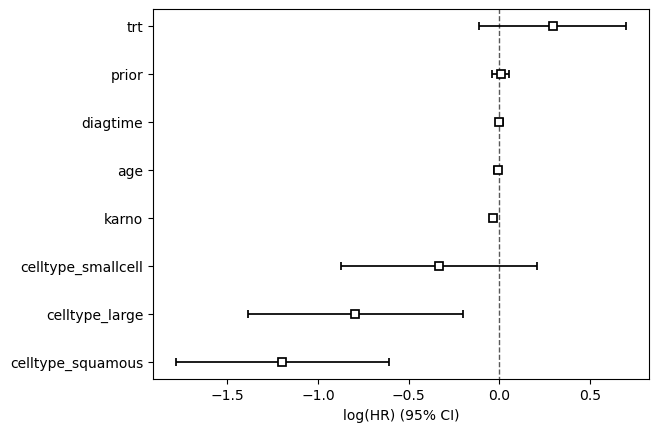

In [26]:
# Plotting
model.plot()